# Fase 7b: Benchmarking de inferencia de modelos de lenguaje
---
Este cuaderno documenta un *benchmarking* entre 5 modelos a los que se ha sometido a pruebas de estrés frente a una muestra de 10 canciones. La evaluación se centra en tres ejes fundamentales: 
1. **Calidad cualitativa:** ¿Qué modelo redacta mejor en español? ¿Cuál entiende mejor las metáforas?
2. **Latencia:** ¿Cuánto tarda cada uno en responder?
3. **Tasa de fallos:** ¿Cuál permite procesar datos en lote sin bloquearse por límites de cuota?

Estas pruebas son relevantes ya que la viabilidad de un sistema de IA en producción no depende únicamente de la precisión del modelo, sino de su eficiencia computacional. Ejecutar inferencia sobre grandes conjuntos de canciones puede generar cuellos de botella y exceder los límites de cuota de las APIs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import time
import os

from groq import Groq
from dotenv import load_dotenv

In [2]:
load_dotenv()
client = Groq(api_key=os.getenv("GROP_API_KEY"))

In [3]:
df = pd.read_csv('../data/processed/taylor_swift_metrics.csv')
df_benchmark = df.iloc[[9, 85, 188, 111, 170, 23, 60, 176, 227, 239]].copy()

In [4]:
models = [
    "llama-3.1-8b-instant", 
    "meta-llama/llama-4-scout-17b-16e-instruct", 
    "qwen/qwen3-32b", 
    "llama-3.3-70b-versatile", 
    "moonshotai/kimi-k2-instruct"
]

In [5]:
results = []

for model in models:
    print(f"Probando modelo: {model}...")

    for idx, row in df_benchmark.iterrows():
        title = row['title']
        lyrics = str(row['lyrics_full'])[:1500]

        prompt = f"""
        Read the lyrics of the song '{title}' by Taylor Swift: "{lyrics}".

        Write a single, brief paragraph (maximum 5 lines) IN SPANISH explaining the story behind this song and its main message.

        Respond strictly IN SPANISH.
        """

        try:
            start_time = time.time()

            response = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": "You are an expert music analyst and literary critic."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.7,
                max_tokens=200
            )

            end_time = time.time()
            total_time = round(end_time - start_time, 2)
            text = response.choices[0].message.content.strip()

            results.append({
                "Canción": title,
                "Modelo": model,
                "Tiempo (s)": total_time,
                "Resumen": text
            })

            time.sleep(3)

        except Exception as e:
            print(f"Error con {model} en {title}: {e}")
            time.sleep(15)

Probando modelo: llama-3.1-8b-instant...
Probando modelo: meta-llama/llama-4-scout-17b-16e-instruct...
Probando modelo: qwen/qwen3-32b...
Probando modelo: llama-3.3-70b-versatile...
Probando modelo: moonshotai/kimi-k2-instruct...


In [6]:
df_results = pd.DataFrame(results)
df_results.sort_values(by="Canción", inplace=True)

In [7]:
for song in df_results["Canción"].unique():
    print("\n" + "="*80)
    print(f"COMPARATIVA PARA LA CANCIÓN: {song}")
    print("="*80)

    song_results = df_results[df_results["Canción"] == song]

    for index, row in song_results.iterrows():
        print(f"MODELO: {row["Modelo"]} (Tardó {row["Tiempo (s)"]} segundos)")
        print(f"RESUMEN: {row["Resumen"]}\n")


COMPARATIVA PARA LA CANCIÓN: CANCELLED!
MODELO: moonshotai/kimi-k2-instruct (Tardó 1.09 segundos)
RESUMEN: La canción retrata a una figura pública arrastrada por la hoguera mediática del “cancel culture”: de un día al otro, la multitud que la vitoreó la entierra con memes y titulares. En vez de arrepentirse, Taylor construye un submundo donde los desgraciados—los cancelados, los burlados—encienden su propio brillo con Gucci, whiskey y cicatrices compartidas. El mensaje: cuando la moralina de internet te depreda, no te arrodilles; reúne a tus leales, abraza el escándalo y aprende “el arte de nunca ser atrapado”; la verdadera pertenencia nace cuando los que se quedan llevan tus mismas heridas.

MODELO: meta-llama/llama-4-scout-17b-16e-instruct (Tardó 0.44 segundos)
RESUMEN: La canción "CANCELLED!" de Taylor Swift parece abordar la temática de la cancelación pública y la toxicidad en las relaciones. La letra describe una situación en la que alguien ha sido "cancelado" por supuestas falta

### 7b.1 Evaluación cuantitativa
En la arquitectura de sistemas escalables, el tiempo de ejecución es crítico. A continuación, se agruparon los resultados por modelo para calcular el tiempo medio de respuesta en segundos.

In [8]:
times = df_results.groupby('Modelo')['Tiempo (s)'].mean().reset_index()
times = times.sort_values(by='Tiempo (s)', ascending=True)

In [9]:
print("--- TIEMPO MEDIO DE INFERENCIA POR MODELO ---")
for idx, row in times.iterrows():
    print(f"{row['Modelo']}: {row['Tiempo (s)']:.2f} segundos")

--- TIEMPO MEDIO DE INFERENCIA POR MODELO ---
meta-llama/llama-4-scout-17b-16e-instruct: 0.44 segundos
llama-3.1-8b-instant: 0.47 segundos
llama-3.3-70b-versatile: 0.67 segundos
qwen/qwen3-32b: 0.78 segundos
moonshotai/kimi-k2-instruct: 0.88 segundos


C:\Users\andre\AppData\Local\Temp\ipykernel_14100\584696291.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=times, x='Tiempo (s)', y='Modelo', palette='magma')


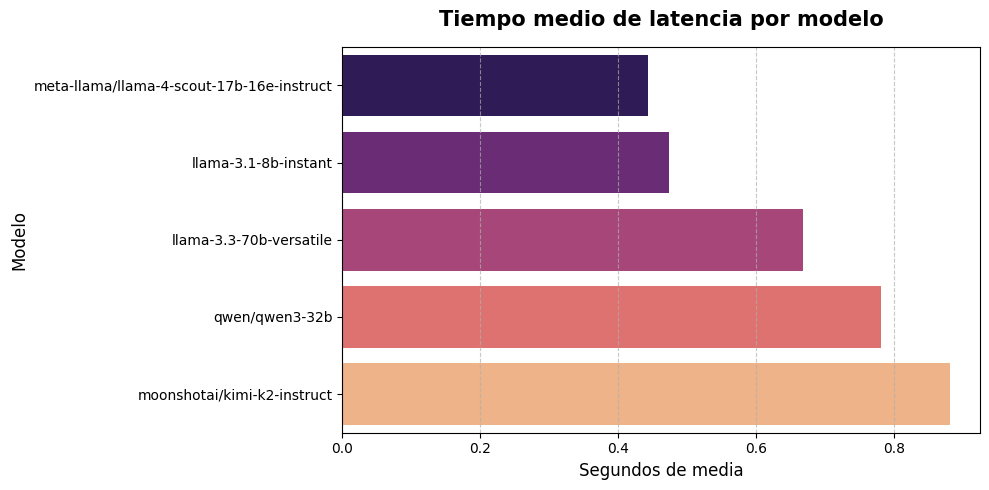

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(data=times, x='Tiempo (s)', y='Modelo', palette='magma')
plt.title('Tiempo medio de latencia por modelo', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Segundos de media', fontsize=12)
plt.ylabel('Modelo', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 7b.2 Evaluación cualitativa
Se extrajeron los resúmenes generados para la canción *marjorie*, porque es una canción de alta carga emocional con metáforas sutiles, lo que supone un buen elemento de prueba para comprobar si el modelo comprende la poesía o si devuelve traducciones robóticas y literales.

In [11]:
song = "marjorie"

print(f"========== EVALUACIÓN CUALITATIVA: {song.upper()} ==========\n")

results_song = df_results[df_results['Canción'] == song]

for idx, row in results_song.iterrows():
    print(f"MODELO: {row['Modelo']} | TIEMPO: {row['Tiempo (s)']}s")
    print(f"RESUMEN:\n{row['Resumen']}")
    print("-" * 80 + "\n")

========== EVALUACIÓN CUALITATIVA: MARJORIE ==========

MODELO: moonshotai/kimi-k2-instruct | TIEMPO: 1.01s
RESUMEN:
“Marjorie” es un tributo a la abuela de Taylor, Marjorie Finlay, una cantante de ópera que falleció cuando Taylor tenía 13 años. La canción narra cómo los consejos de su abuela —ser amable e inteligente, ejercer el poder con cortesía— siguen vivos en su mente. A través de recuerdos cotidianos —el cielo ámbar, los nados en agua fría, los recibos del supermercado— Taylor reconstruye la presencia de Marjorie y celebra que, aunque físicamente ha muerto, su legado y voz permanecen. El mensaje central es que el amor y la sabiduría trascienden la muerte, y que la memoria activa mantiene “viva” a quien se ha ido
--------------------------------------------------------------------------------

MODELO: meta-llama/llama-4-scout-17b-16e-instruct | TIEMPO: 0.42s
RESUMEN:
La canción "Marjorie" de Taylor Swift parece ser un tributo a una persona que ha fallecido, posiblemente una figur

In [12]:
df_results.to_csv('../data/processed/benchmark_results.csv', index=False)

### Conclusión del benchmark
Tras ponderar los resultados cuantitativos y cualitativos de los 5 modelos evaluados, se llegó a las siguientes conclusiones:

* Los modelos pesados (`llama-3.3-70b-versatile`, `meta-llama/llama-4-scout-17b-16e-instruct`, `qwen/qwen3-32b`) ofrecen redacciones literarias muy ricas y un buen dominio del idioma, pero su alta latencia y su tendencia a agotar los límites de cuota de la API los descartan.
* `moonshotai/kimi-k2-instruct`, a pesar de estar diseñado para ventanas de contexto extremadamente largas, no aportó una mejora cualitativa significativa frente a los otros modelos y presentó ciertas inconsistencias a la hora de seguir instrucciones estrictas de formato.
* `llama-3.1-8b-instant` alcanzó una calidad literaria casi idéntica a `llama-3.3-70b-versatile` o `meta-llama/llama-4-scout-17b-16e-instruct`, pero con una latencia mucho menor y muchos menos parámetros, por lo que se decidió implementarlo como el motor LLM principal del proyecto.